# On-Policy Reverse KLD Distillation: Indian History

**Teacher**: Qwen3-14B (4-bit NF4)  
**Student**: Qwen3-1.7B (bf16)  
**Mode**: Non-thinking (`enable_thinking=False`)  
**Method**: On-policy reverse KL divergence — student generates rollouts, teacher provides the distillation signal  
**Dataset**: 580 controversial Indian history questions (`indianhistory_tagged.jsonl`)  
**Hardware**: L4 (24 GB VRAM)

In [1]:
# CELL 1: Environment Setup & Dependencies

# Remove broken torchvision/torchaudio that crash transformers due to CUDA version mismatch
!pip uninstall -y torchvision torchaudio

# Install required libraries (do NOT upgrade torch — Colab's pre-installed version is correct)
!pip install -U -q "transformers>=4.51.0" datasets accelerate bitsandbytes tiktoken einops

# Set CUDA allocator to handle fragmentation better
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 155.7 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 51.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 45.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 54.9 MB/s eta 0:00:00:00:0100:01
PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 22.0 GB


In [2]:
# CELL 2: Upload & Load Dataset

import json
import os

# Define the path to your dataset file
# Ensure you have dragged/uploaded this file to your runtime file explorer
DATA_PATH = "fully_tagged_dataset.jsonl" 

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find '{DATA_PATH}'. "
        "Please use your IDE or Colab file explorer sidebar to manually upload the file directly to the runtime before running this cell."
    )

# Parse the dataset
dataset = []
with open(DATA_PATH, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            dataset.append(json.loads(line))

print(f"\nLoaded {len(dataset)} questions from {DATA_PATH}")

# Tag distribution summary
from collections import Counter
tp_counts = Counter(d["time_period_tag"] for d in dataset)
t_counts = Counter(d["tonal_tag"] for d in dataset)
print(f"\nTime-Period distribution: {dict(sorted(tp_counts.items()))}")
print(f"Tonal distribution:       {dict(sorted(t_counts.items()))}")

assert len(dataset) > 0, "Dataset is empty!"
assert all("messages" in d and "time_period_tag" in d and "tonal_tag" in d for d in dataset), "Malformed entries"



Loaded 580 questions from fully_tagged_dataset.jsonl

Time-Period distribution: {'TP-A': 138, 'TP-B': 280, 'TP-C': 141, 'TP-D': 21}
Tonal distribution:       {'T-A': 285, 'T-B': 21, 'T-C': 61, 'T-D': 213}


In [3]:
# CELL 3: Train / Eval Split (Proportional Stratified Sampling)

import random
from collections import defaultdict, Counter

random.seed(42)

# 1. Group by both tonal tag and time_period tag
by_combo = defaultdict(list)
for item in dataset:
    by_combo[(item["tonal_tag"], item["time_period_tag"])].append(item)

train_data = []
eval_data = []

# 2. Define the target proportion
total_samples = len(dataset)
target_eval_size = 80  # Adjust this if you want a larger or smaller eval set
eval_fraction = target_eval_size / total_samples if total_samples > 0 else 0.1

# 3. Sample proportionally from each combination bucket
for combo, items in sorted(by_combo.items()):
    random.shuffle(items)

    # Calculate the proportional number of eval samples for this specific bucket
    n_eval = int(round(len(items) * eval_fraction))

    # Fallback: Ensure at least 1 eval sample is taken if the bucket exists,
    # to guarantee coverage of rare edge cases in the eval set.
    if len(items) > 0 and n_eval == 0:
        n_eval = 1

    # Ensure we don't take more samples than exist in the bucket
    n_eval = min(n_eval, len(items))

    eval_data.extend(items[:n_eval])
    train_data.extend(items[n_eval:])

# 4. Shuffle the final sets so batches aren't clustered by taxonomy
random.shuffle(train_data)
random.shuffle(eval_data)

print(f"Total Dataset Size: {total_samples}")
print(f"Train Size: {len(train_data)} | Eval Size: {len(eval_data)}")
print(f"Eval tonal breakdown: {dict(Counter(d['tonal_tag'] for d in eval_data))}")
print(f"Eval time-period breakdown: {dict(Counter(d['time_period_tag'] for d in eval_data))}")

Total Dataset Size: 580
Train Size: 498 | Eval Size: 82
Eval tonal breakdown: {'T-A': 39, 'T-D': 30, 'T-C': 9, 'T-B': 4}
Eval time-period breakdown: {'TP-B': 39, 'TP-A': 19, 'TP-C': 19, 'TP-D': 5}


In [4]:
# CELL 4: Model Initialization (Teacher + Student, Non-Thinking Mode)

import gc
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

# Clear any residual GPU memory from prior failed attempts
gc.collect()
torch.cuda.empty_cache()

TEACHER_ID = "Qwen/Qwen3-4B"
STUDENT_ID = "Qwen/Qwen3-1.7B"

# Shared tokenizer — both are Qwen3 family, same vocab
print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(STUDENT_ID, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # for generation compatibility

# Teacher: full bf16, frozen — NO quantization (bypasses broken bitsandbytes conversion)
# Qwen3-4B @ bf16 ≈ 8 GB VRAM — fits comfortably on L4
print(f"Loading Teacher ({TEACHER_ID}) in bf16...")
teacher_model = AutoModelForCausalLM.from_pretrained(
    TEACHER_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
teacher_model.eval()
for param in teacher_model.parameters():
    param.requires_grad = False
print(f"  Teacher loaded. VRAM: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

# Student: full bf16, trainable, gradient checkpointing for VRAM savings
print(f"Loading Student ({STUDENT_ID}) in bf16...")
student_model = AutoModelForCausalLM.from_pretrained(
    STUDENT_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
student_model.gradient_checkpointing_enable()
student_model.train()

# Verify tokenizer compatibility
teacher_tok = AutoTokenizer.from_pretrained(TEACHER_ID, trust_remote_code=True)
assert tokenizer.vocab_size == teacher_tok.vocab_size, \
    f"Vocab mismatch! Student: {tokenizer.vocab_size}, Teacher: {teacher_tok.vocab_size}"
del teacher_tok

print(f"\nTeacher params: {sum(p.numel() for p in teacher_model.parameters()) / 1e9:.2f}B")
print(f"Student params: {sum(p.numel() for p in student_model.parameters()) / 1e9:.2f}B")
print(f"VRAM used: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")


Loading tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]


Teacher params: 4.02B
Student params: 1.72B
VRAM used: 10.7 GB


In [5]:
# CELL 5: Prompt Formatting (Non-Thinking Chat Template)

SYSTEM_PROMPT = (
    "You are a knowledgeable historian specializing in Indian history. "
    "Provide balanced, well-reasoned, and nuanced answers to questions about Indian history. Do not be verbose, you have to be well reasoned yet concise. "
    "Acknowledge multiple perspectives where they exist. "
    "Be factually accurate and cite relevant historical context."
    
)

def format_prompt(question_text: str) -> str:
    """Format a question into a Qwen3 chat prompt with enable_thinking=False."""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question_text},
    ]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=False,  # Non-thinking mode
    )
    return text

# Quick sanity check
sample_prompt = format_prompt(train_data[0]["messages"][0]["content"])
print("=== Sample formatted prompt ===")
print(sample_prompt)
print(f"\nTokenized length: {len(tokenizer.encode(sample_prompt))} tokens")

=== Sample formatted prompt ===
<|im_start|>system
You are a knowledgeable historian specializing in Indian history. Provide balanced, well-reasoned, and nuanced answers to questions about Indian history. Do not be verbose, you have to be well reasoned yet concise. Acknowledge multiple perspectives where they exist. Be factually accurate and cite relevant historical context.<|im_end|>
<|im_start|>user
Examine the role played by zamindars in Mughal India.<|im_end|>
<|im_start|>assistant
<think>

</think>



Tokenized length: 91 tokens


In [6]:
# CELL 6: On-Policy Reverse KLD Distillation Training Loop

import torch.nn.functional as F
import math
import time
import random
from transformers.optimization import Adafactor

# ─── Hyperparameters ───
MICRO_BATCH_SIZE = 1           # Per-step micro batch
GRAD_ACCUM_STEPS = 8           # Effective batch size = 8
EPOCHS = 1
LR = 2e-5
WARMUP_RATIO = 0.1
MAX_NEW_TOKENS = 512           # Student rollout length
MAX_SEQ_LEN = 896              # Total sequence length cap (prompt + completion)

# Non-thinking sampling parameters (Qwen3 recommended)
GEN_KWARGS = dict(
    max_new_tokens=MAX_NEW_TOKENS,
    temperature=0.7,
    top_p=0.8,
    top_k=20,
    do_sample=True,
    pad_token_id=tokenizer.pad_token_id,
)

# ─── Optimizer & Scheduler (Adafactor — no bitsandbytes needed) ───
optimizer = Adafactor(
    student_model.parameters(),
    lr=LR,
    scale_parameter=False,
    relative_step=False,
    warmup_init=False,
    weight_decay=0.01,
)

total_steps = math.ceil(len(train_data) / MICRO_BATCH_SIZE) * EPOCHS
opt_steps = total_steps // GRAD_ACCUM_STEPS
warmup_steps = int(opt_steps * WARMUP_RATIO)

def get_lr(step):
    """Linear warmup then cosine decay."""
    if step < warmup_steps:
        return step / max(1, warmup_steps)
    progress = (step - warmup_steps) / max(1, opt_steps - warmup_steps)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, get_lr)

print(f"Training config:")
print(f"  Train samples: {len(train_data)}")
print(f"  Micro batch:   {MICRO_BATCH_SIZE}")
print(f"  Grad accum:    {GRAD_ACCUM_STEPS}")
print(f"  Eff batch:     {MICRO_BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"  Epochs:        {EPOCHS}")
print(f"  Total steps:   {total_steps}")
print(f"  Optimizer steps: {opt_steps}")
print(f"  Warmup steps:  {warmup_steps}")
print(f"  Max rollout:   {MAX_NEW_TOKENS} tokens")
print(f"  Optimizer:     Adafactor (memory-efficient)")

# ─── Training Loop ───
loss_history = []
global_step = 0
opt_step = 0

train_start_time = time.time()
total_gen_time = 0

for epoch in range(EPOCHS):
    random.shuffle(train_data)
    epoch_losses = []
    epoch_start = time.time()
    epoch_gen_time = 0

    for i in range(0, len(train_data), MICRO_BATCH_SIZE):
        batch = train_data[i : i + MICRO_BATCH_SIZE]

        # ── Step 1: Format prompts ──
        prompts = [format_prompt(item["messages"][0]["content"]) for item in batch]
        prompt_inputs = tokenizer(
            prompts, return_tensors="pt", padding=True, truncation=True, max_length=384
        ).to("cuda:0")
        prompt_len = prompt_inputs["input_ids"].shape[1]

        # ── Step 2: On-policy rollout — student generates completions ──
        student_model.eval()
        gen_start = time.time()
        with torch.no_grad():
            generated_ids = student_model.generate(
                **prompt_inputs,
                **GEN_KWARGS,
            )
        gen_time = time.time() - gen_start
        epoch_gen_time += gen_time
        total_gen_time += gen_time
        student_model.train()

        # Truncate to max sequence length
        if generated_ids.shape[1] > MAX_SEQ_LEN:
            generated_ids = generated_ids[:, :MAX_SEQ_LEN]

        completion_len = generated_ids.shape[1] - prompt_len
        if completion_len < 2:
            continue

        attention_mask = (generated_ids != tokenizer.pad_token_id).long()

        # ── Step 3: Forward pass through both models ──
        with torch.no_grad():
            teacher_outputs = teacher_model(
                input_ids=generated_ids,
                attention_mask=attention_mask,
            )
            teacher_logits = teacher_outputs.logits

        student_outputs = student_model(
            input_ids=generated_ids,
            attention_mask=attention_mask,
        )
        student_logits = student_outputs.logits

        # ── Step 4: Reverse KLD on completion tokens ──
        s_logits = student_logits[:, prompt_len - 1 : -1, :]
        t_logits = teacher_logits[:, prompt_len - 1 : -1, :]
        comp_mask = attention_mask[:, prompt_len:]

        log_p_student = F.log_softmax(s_logits, dim=-1)
        log_p_teacher = F.log_softmax(t_logits, dim=-1)
        p_student = F.softmax(s_logits, dim=-1)

        per_token_kld = (p_student * (log_p_student - log_p_teacher)).sum(dim=-1)
        masked_kld = per_token_kld * comp_mask.float()
        loss = masked_kld.sum() / comp_mask.sum().clamp(min=1)

        scaled_loss = loss / GRAD_ACCUM_STEPS
        scaled_loss.backward()

        epoch_losses.append(loss.item())
        loss_history.append(loss.item())
        global_step += 1

        # ── Step 5: Optimizer step every GRAD_ACCUM_STEPS ──
        if global_step % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            opt_step += 1

        # Logging
        if global_step % 20 == 0:
            avg_recent = sum(epoch_losses[-20:]) / len(epoch_losses[-20:])
            lr_now = scheduler.get_last_lr()[0]
            vram = torch.cuda.memory_allocated() / 1024**3
            elapsed_so_far = time.time() - train_start_time
            avg_step_time = elapsed_so_far / global_step
            eta_mins = ((total_steps - global_step) * avg_step_time) / 60
            avg_gen = total_gen_time / global_step
            print(
                f"Epoch {epoch+1}/{EPOCHS} | Step {global_step}/{total_steps} | "
                f"Reverse KLD: {loss.item():.4f} | Avg(20): {avg_recent:.4f} | "
                f"LR: {lr_now:.2e} | VRAM: {vram:.1f}GB | "
                f"ETA: {eta_mins:.1f}m | GenTime/step: {avg_gen:.2f}s"
            )

        # Free VRAM
        del teacher_outputs, student_outputs, teacher_logits, student_logits
        del s_logits, t_logits, log_p_student, log_p_teacher, p_student
        del generated_ids, prompt_inputs, attention_mask
        torch.cuda.empty_cache()

    # Flush remaining gradients at epoch end
    if global_step % GRAD_ACCUM_STEPS != 0:
        torch.nn.utils.clip_grad_norm_(student_model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        opt_step += 1

    epoch_avg = sum(epoch_losses) / len(epoch_losses)
    elapsed = time.time() - epoch_start
    print(f"\n{'='*70}")
    print(f"Epoch {epoch+1}/{EPOCHS} Complete | Avg Reverse KLD: {epoch_avg:.4f} | Time: {elapsed/60:.1f}min (Gen: {epoch_gen_time/60:.1f}min)")
    print(f"{'='*70}\n")

total_training_time = time.time() - train_start_time
print(f"\nTotal Training Time: {total_training_time / 60:.1f} minutes")
print(f"Total Generation Time during Training: {total_gen_time / 60:.1f} minutes\n")

q1_avg = sum(loss_history[:len(loss_history)//3]) / max(1, len(loss_history)//3)
q3_avg = sum(loss_history[-len(loss_history)//3:]) / max(1, len(loss_history)//3)
print(f"\nLoss trend: First third avg={q1_avg:.4f} → Last third avg={q3_avg:.4f}")
if q3_avg < q1_avg:
    print("✓ Loss is decreasing — distillation is working.")
else:
    print("⚠ Loss did not decrease — check hyperparameters.")


Training config:
  Train samples: 498
  Micro batch:   1
  Grad accum:    8
  Eff batch:     8
  Epochs:        1
  Total steps:   498
  Optimizer steps: 62
  Warmup steps:  6
  Max rollout:   512 tokens
  Optimizer:     Adafactor (memory-efficient)


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Epoch 1/1 | Step 20/498 | Reverse KLD: 0.9413 | Avg(20): 1.0054 | LR: 6.67e-06 | VRAM: 14.4GB | ETA: 86.5m | GenTime/step: 10.32s
Epoch 1/1 | Step 40/498 | Reverse KLD: 0.6646 | Avg(20): 0.8684 | LR: 1.67e-05 | VRAM: 11.4GB | ETA: 100.4m | GenTime/step: 12.59s
Epoch 1/1 | Step 60/498 | Reverse KLD: 1.1639 | Avg(20): 1.0033 | LR: 2.00e-05 | VRAM: 14.5GB | ETA: 97.6m | GenTime/step: 12.80s
Epoch 1/1 | Step 80/498 | Reverse KLD: 0.9263 | Avg(20): 0.8844 | LR: 1.97e-05 | VRAM: 11.4GB | ETA: 97.1m | GenTime/step: 13.36s
Epoch 1/1 | Step 100/498 | Reverse KLD: 0.8341 | Avg(20): 0.8595 | LR: 1.94e-05 | VRAM: 14.8GB | ETA: 95.6m | GenTime/step: 13.83s
Epoch 1/1 | Step 120/498 | Reverse KLD: 0.9691 | Avg(20): 0.8716 | LR: 1.88e-05 | VRAM: 11.3GB | ETA: 92.5m | GenTime/step: 14.09s
Epoch 1/1 | Step 140/498 | Reverse KLD: 1.1501 | Avg(20): 0.9345 | LR: 1.82e-05 | VRAM: 14.4GB | ETA: 87.1m | GenTime/step: 14.02s
Epoch 1/1 | Step 160/498 | Reverse KLD: 0.8781 | Avg(20): 0.8903 | LR: 1.71e-05 | VRAM

In [7]:
# CELL 7: Generate Answers for LLM-as-a-Judge Evaluation

import json
import time
import torch

def generate_eval_answers(eval_samples, micro_batch=4, output_file="eval_student_generations.jsonl"):
    """Generate responses for the held-out eval set and save to JSONL."""
    # Put model into eval mode for clean generation
    student_model.eval()
    results = []
    eval_start_time = time.time()
    
    print(f"Starting generation for {len(eval_samples)} eval samples...")
    print(f"Saving outputs iteratively to: {output_file}\n")
    
    with torch.no_grad():
        with open(output_file, "w", encoding="utf-8") as f:
            for i in range(0, len(eval_samples), micro_batch):
                batch = eval_samples[i : i + micro_batch]
                
                # Extract the original questions
                questions = [item["messages"][0]["content"] for item in batch]
                # Format prompts using the exact template from training
                prompts = [format_prompt(q) for q in questions]

                prompt_inputs = tokenizer(
                    prompts, return_tensors="pt", padding=True, truncation=True, max_length=384
                ).to("cuda:0")
                
                prompt_len = prompt_inputs["input_ids"].shape[1]

                # Generate! Notice we set use_cache=True here. 
                # Since we don't need grad checkpointing for eval, this makes it WAY faster.
                gen_start = time.time()
                generated_ids = student_model.generate(
                    **prompt_inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    temperature=0.7,
                    top_p=0.8,
                    top_k=20,
                    do_sample=True,
                    pad_token_id=tokenizer.pad_token_id,
                    use_cache=True  
                )
                
                # Extract only the newly generated completion tokens (drop the prompt)
                completion_ids = generated_ids[:, prompt_len:]
                completions = tokenizer.batch_decode(completion_ids, skip_special_tokens=True)
                
                # Save results iteratively so nothing is lost if it crashes
                for j in range(len(batch)):
                    entry = {
                        "question": questions[j],
                        "student_answer": completions[j].strip(),
                        "time_period_tag": batch[j].get("time_period_tag", ""),
                        "tonal_tag": batch[j].get("tonal_tag", "")
                    }
                    results.append(entry)
                    f.write(json.dumps(entry, ensure_ascii=False) + "\n")
                
                # Clean up memory after every batch
                del prompt_inputs, generated_ids, completion_ids
                torch.cuda.empty_cache()

                # Logging
                batch_idx = i // micro_batch
                total_batches = (len(eval_samples) + micro_batch - 1) // micro_batch
                if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == total_batches:
                    elapsed = time.time() - eval_start_time
                    avg_batch_time = elapsed / (batch_idx + 1)
                    eta_mins = ((total_batches - (batch_idx + 1)) * avg_batch_time) / 60
                    print(f"Eval Batch {batch_idx+1}/{total_batches} | ETA: {eta_mins:.1f}m")

    total_eval_time = time.time() - eval_start_time
    print(f"\nEval Completed. Total Time: {total_eval_time / 60:.1f} minutes")
    print(f"Successfully saved {len(results)} output generations to '{output_file}'!")
    
    # Put model back into train mode just in case
    student_model.train()
    return results

# Kick off the generation
eval_generations = generate_eval_answers(eval_data, micro_batch=4)


Starting generation for 82 eval samples...
Saving outputs iteratively to: eval_student_generations.jsonl

Eval Batch 5/21 | ETA: 6.3m
Eval Batch 10/21 | ETA: 4.1m
Eval Batch 15/21 | ETA: 2.2m
Eval Batch 20/21 | ETA: 0.4m
Eval Batch 21/21 | ETA: 0.0m

Eval Completed. Total Time: 7.8 minutes
Successfully saved 82 output generations to 'eval_student_generations.jsonl'!


In [10]:
from google.colab import files

# Download the student generation file
files.download("eval_student_generations.jsonl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [11]:
from google.colab import drive
import shutil

# This will prompt you to authorize Google Drive access
drive.mount('/content/drive')

# Copy the file directly to your Google Drive root folder
shutil.copy("eval_student_generations.jsonl", "/content/drive/MyDrive/eval_student_generations.jsonl")

print("File successfully copied to your Google Drive!")


Mounted at /content/drive
File successfully copied to your Google Drive!


In [13]:
# CELL 9: Save Distilled Student Model Directly to Google Drive

from google.colab import drive
import json
import os

# 1. Ensure Google Drive is mounted
drive.mount('/content/drive')

# 2. Define the path directly inside your Google Drive
SAVE_DIR = "/content/drive/MyDrive/distilled_qwen3_1.7b_indian_history"
os.makedirs(SAVE_DIR, exist_ok=True)

print(f"Saving model and tokenizer directly to {SAVE_DIR}...")
print("This may take 1-2 minutes depending on Drive write speeds...")

# 3. Save the model and tokenizer directly to Drive
student_model.eval()
student_model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

# 4. Save training metadata
metadata = {
    "teacher_model": TEACHER_ID,
    "student_model": STUDENT_ID,
    "method": "on-policy reverse KLD",
    "mode": "non-thinking (enable_thinking=False)",
    "dataset": "indianhistory_tagged.jsonl",
    "train_samples": len(train_data),
    "eval_samples": len(eval_data),
    "epochs": EPOCHS,
    "learning_rate": LR,
    "micro_batch_size": MICRO_BATCH_SIZE,
    "grad_accum_steps": GRAD_ACCUM_STEPS,
    "max_new_tokens": MAX_NEW_TOKENS,
    "max_seq_len": MAX_SEQ_LEN,
    "final_avg_loss": loss_history[-1] if loss_history else None,
}

with open(f"{SAVE_DIR}/training_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"\nSUCCESS! Model, tokenizer, and metadata are permanently safe in your Google Drive.")
print("You can load this model anywhere using:")
print(f'AutoModelForCausalLM.from_pretrained("{SAVE_DIR}")')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saving model and tokenizer directly to /content/drive/MyDrive/distilled_qwen3_1.7b_indian_history...
This may take 1-2 minutes depending on Drive write speeds...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


SUCCESS! Model, tokenizer, and metadata are permanently safe in your Google Drive.
You can load this model anywhere using:
AutoModelForCausalLM.from_pretrained("/content/drive/MyDrive/distilled_qwen3_1.7b_indian_history")


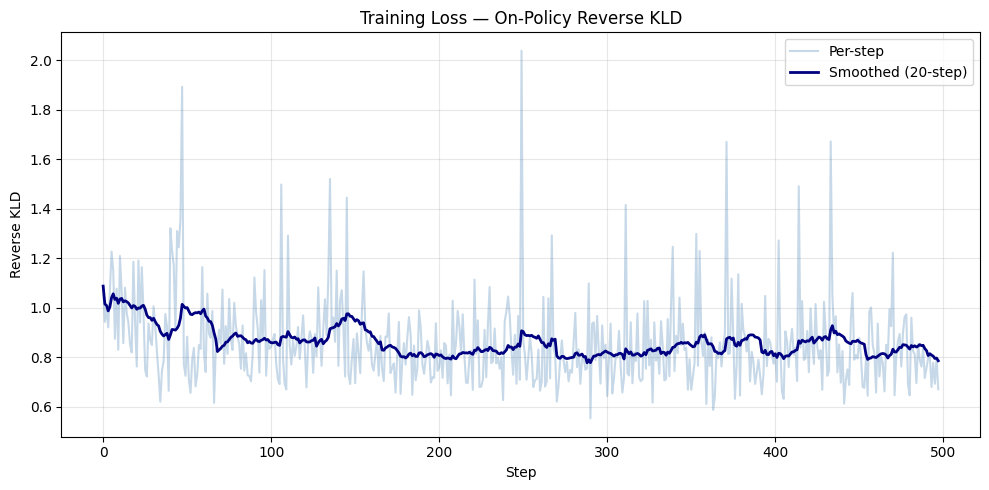

Saved training_curves.png


In [14]:
# CELL 10: Loss Curve Visualization

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Raw loss curve
plt.plot(loss_history, alpha=0.3, color="steelblue", label="Per-step")

# Smoothed (rolling average over 20 steps)
window = 20
if len(loss_history) >= window:
    smoothed = [
        sum(loss_history[max(0, i-window):i+1]) / len(loss_history[max(0, i-window):i+1])
        for i in range(len(loss_history))
    ]
    plt.plot(smoothed, color="navy", linewidth=2, label=f"Smoothed ({window}-step)")

plt.xlabel("Step")
plt.ylabel("Reverse KLD")
plt.title("Training Loss — On-Policy Reverse KLD")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

print("Saved training_curves.png")


In [15]:
# CELL 11: Base Model (Pre-Distillation) Evaluation

import gc
import json
import time
import torch
from transformers import AutoModelForCausalLM

print("Clearing VRAM from the training session...")
# Delete the huge models from memory so we don't OOM our L4 GPU
try:
    del student_model
    del teacher_model
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

BASE_MODEL_ID = "Qwen/Qwen3-1.7B"

print(f"Loading Base Model ({BASE_MODEL_ID}) for baseline comparison...")
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)
base_model.eval()

def generate_baseline_answers(model, eval_samples, micro_batch=4, output_file="eval_base_generations.jsonl"):
    """Generate responses for the held-out eval set using the UN-DISTILLED model."""
    results = []
    eval_start_time = time.time()
    
    print(f"\nStarting baseline generation for {len(eval_samples)} eval samples...")
    print(f"Saving outputs iteratively to: {output_file}\n")
    
    with torch.no_grad():
        with open(output_file, "w", encoding="utf-8") as f:
            for i in range(0, len(eval_samples), micro_batch):
                batch = eval_samples[i : i + micro_batch]
                
                questions = [item["messages"][0]["content"] for item in batch]
                # Reusing the exact same prompt formatter from earlier
                prompts = [format_prompt(q) for q in questions]

                prompt_inputs = tokenizer(
                    prompts, return_tensors="pt", padding=True, truncation=True, max_length=384
                ).to("cuda:0")
                
                prompt_len = prompt_inputs["input_ids"].shape[1]

                # Generate using the BASE model
                generated_ids = model.generate(
                    **prompt_inputs,
                    max_new_tokens=MAX_NEW_TOKENS,
                    temperature=0.7,
                    top_p=0.8,
                    top_k=20,
                    do_sample=True,
                    pad_token_id=tokenizer.pad_token_id,
                    use_cache=True  
                )
                
                completion_ids = generated_ids[:, prompt_len:]
                completions = tokenizer.batch_decode(completion_ids, skip_special_tokens=True)
                
                for j in range(len(batch)):
                    entry = {
                        "question": questions[j],
                        "base_answer": completions[j].strip(),  # Note the changed key name
                        "time_period_tag": batch[j].get("time_period_tag", ""),
                        "tonal_tag": batch[j].get("tonal_tag", "")
                    }
                    results.append(entry)
                    f.write(json.dumps(entry, ensure_ascii=False) + "\n")
                
                del prompt_inputs, generated_ids, completion_ids
                torch.cuda.empty_cache()

                batch_idx = i // micro_batch
                total_batches = (len(eval_samples) + micro_batch - 1) // micro_batch
                if (batch_idx + 1) % 5 == 0 or (batch_idx + 1) == total_batches:
                    elapsed = time.time() - eval_start_time
                    avg = elapsed / (batch_idx + 1)
                    eta = ((total_batches - (batch_idx + 1)) * avg) / 60
                    print(f"Baseline Eval Batch {batch_idx+1}/{total_batches} | ETA: {eta:.1f}m")

    total_time = time.time() - eval_start_time
    print(f"\nBaseline Eval Completed. Total Time: {total_time / 60:.1f} minutes")
    print(f"Successfully saved {len(results)} baseline generations to '{output_file}'!")
    return results

# Kick off the evaluation
base_generations = generate_baseline_answers(
    model=base_model, 
    eval_samples=eval_data, 
    micro_batch=4, 
    output_file="eval_base_generations.jsonl"
)


Clearing VRAM from the training session...
Loading Base Model (Qwen/Qwen3-1.7B) for baseline comparison...


Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]


Starting baseline generation for 82 eval samples...
Saving outputs iteratively to: eval_base_generations.jsonl

Baseline Eval Batch 5/21 | ETA: 5.4m
Baseline Eval Batch 10/21 | ETA: 3.5m
Baseline Eval Batch 15/21 | ETA: 2.0m
Baseline Eval Batch 20/21 | ETA: 0.3m
Baseline Eval Batch 21/21 | ETA: 0.0m

Baseline Eval Completed. Total Time: 6.7 minutes
Successfully saved 82 baseline generations to 'eval_base_generations.jsonl'!


In [16]:
import shutil

# Copy the baseline file directly to your Google Drive root folder
shutil.copy("eval_base_generations.jsonl", "/content/drive/MyDrive/eval_base_generations.jsonl")

print("Baseline generations securely copied to Google Drive!")


Baseline generations securely copied to Google Drive!
